## EXPERIMENTING WITH PYTORCH

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim


 IN MY OWN WORDS

|  x  |  w  | -> z , loss = z^2 

To propagate the error backwards, figure out what to adjust the weights by, 

loss.backward takes dL/dz (sensitivty of loss function to a change in z = 12),

multiplies it by the activation (technically transposed) to get the weight's gradient i.e, 12 * 3 = 36. 

What this is saying is that: 
    a) 12 (dL/dz) is the sensisitivy of the loss to a change in Z
    b) in turn the sensitivity of z to w weight was 3, because z = w * x, and deriving that wrt w is 1 * x (1 *3), then dz/dw is 12 * 3 = 36
    c) so the backpropagation is saying, nudging z down by 1 unit will nudge the loss down by 12 units, and because nudging w down by 1 unit will nudge z down by 3 units, so that means when i nudge w down 1, i nudge z down 3, which means loss is nudged down (12 * 3) or 36, so 1 nudge of w is 36 nudges of L, so the gradient (dL/dw) is 36

### Create New Pytorch Neural Net Class

Here, we initialize a neural net using the Pytorch neural network module, creating a class that inherits from the module, we can specifify each layer with the number of features in and out, (e.g. 3x 2)specify a bias, do a forward pass that takes in an input and does the multiplication? (self.layer(x)) we then instatiate our class to do so. 

In [ ]:
class TinyNet(nn.Module): 
    
    def __init__ (self, n_features, n_neurons):
        super().__init__()

        self.layers = nn.ModuleList() #modulelist is a collection-like object for layers 
        
        layer_input = n_features #first layer 


        #for each layer, create a layer with shape (layer_input, n), so that each layer has the right number of inputs and features
        for n in n_neurons:
            layer = nn.Linear(layer_input, n, bias=False) #layer takes in 'layer_input'inputs, and outputs n outbuts
            self.layers.append(layer)
            layer_input = n #the next number of neurons becomes the input 
            
        

    # the forward function is called as soon as our instance is created because of __.call__ method, 
    # it goes through each layer in our collection of layers, calls the layer function which performs a matrix multiplication of layer inputs, 
    #before calling a ReLu activation function, except if we are at the last yayer 

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) -1: 
                x = F.relu(x)

        return x

layer 0: torch.Size([10, 10])
layer 1: torch.Size([8, 10])
layer 2: torch.Size([5, 8])
layer 3: torch.Size([2, 5])
layer 4: torch.Size([1, 2])


### Load and Prep Diabetes Data


In [30]:
from sklearn.datasets import load_diabetes
import pandas as pd

# This dataset tracks disease progression based on age, bmi, bp, etc.
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)

# cell 5
raw_target = data.target
scaled_target = (raw_target - raw_target.mean()) / raw_target.std()
diabetes_df = pd.concat([df, pd.Series(scaled_target, name='target')], axis=1)


features: torch.Size([442, 10]) target: torch.Size([442, 1])
0.7951739430427551
0.2766392230987549
0.9988735318183899
1.7056281566619873
0.8922618627548218
0.7032867670059204
0.49675703048706055
1.0062024593353271
0.927476704120636
0.7676485180854797
0.8867524862289429
1.5619056224822998
0.48370862007141113
1.8508793115615845
1.0234057903289795
1.3098316192626953
0.8795140385627747
0.9846044778823853
0.5433458089828491
0.6994629502296448
0.8114797472953796
1.3463090658187866
0.7624725103378296
1.11686372756958
1.116051435470581
2.0173449516296387
1.291420578956604
0.8837326765060425
0.9242591857910156
1.456831693649292
0.9516195058822632
0.2579874098300934
0.8203967213630676
1.159257411956787
0.49656692147254944
0.9418357014656067
0.6837666630744934
0.3004091680049896
0.5298827886581421
0.6406375169754028
0.5112724900245667
0.6485704183578491
0.19135326147079468
0.809209942817688
0.3415614366531372
0.5293700695037842
0.7869705557823181
0.4579802453517914
0.561495304107666
0.54301738739

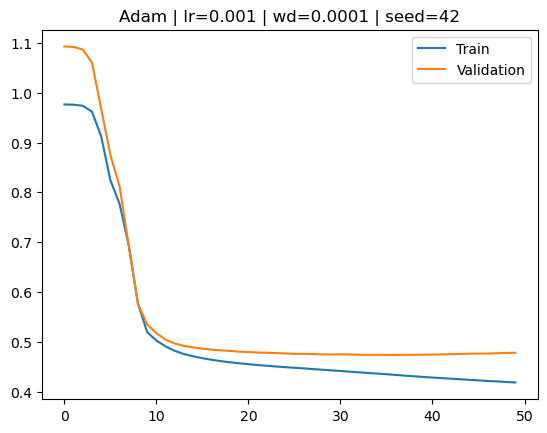

In [ ]:
#0. Seed the init so as to be able compare runs 

torch.manual_seed(42)

# 1. SET UP NEURAL NETWORK 

#set no of features in dataset
n_features = len(diabetes_df[data.feature_names].columns)


#set no of neurons (reduced set of inputs that will be passed into each layer until we get to an output)
#set number of neurons in each layer until output = 1
n_neurons = [10, 8, 5, 2, 1]

#instantiate model with n_features and n_neurons
model = TinyNet(n_features, n_neurons)

#2. DEFINE OPTIMIZATION ALGORITHM

lr = 0.001
wd = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd) #optimizer will do stochastic gradient descent each step, updating each learnable weight after each step

#3. TRANSFORM FEATURES AND TARGET DATA FROM DATAFRAME INTO NUMPY ARRAYS AND THEN INTO TENSORS

#create a tensor for the target, note that it must by in numpy array, which series already is 
#make sure data type is float32, because numpy is float64 and matmul will fail

target_ts = torch.tensor(diabetes_df['target'], dtype=torch.float32).reshape(-1,1)

#convert features dataset to numpy so that torch.tensor an read and convert to tensor 
features_arr = diabetes_df[data.feature_names].to_numpy()
features_ts = torch.tensor(features_arr, dtype = torch.float32)

print("features:", features_ts.shape, "target:", target_ts.shape) 

test_size = int(0.2 * features_ts.shape[0])

X_train_ts = features_ts[:-test_size]
X_test_ts = features_ts[-test_size:]

y_train_ts = target_ts[:-test_size]
y_test_ts = target_ts[-test_size:]



#set batch size, no. of epochs in preparation for training

batch_size = 10 
n_epochs = 50


#4. PER EPOCH AND PER BATCH, perform forward pass through our neutral network, matrix multiplication through the layers generates an output for each observation in the sample
epoch_counts = []
all_tr_loss = []
all_val_loss = []

for i in range(0, n_epochs):

    batch_tr_loss = []
    batch_val_loss = []
    
    for j in range(0, len(X_train_ts), batch_size):
        #zero out gradients to reset for each forward pass
        optimizer.zero_grad()

        batch = X_train_ts[j:j+batch_size]
        batch_output = model(batch)
        batch_true = y_train_ts[j:j+batch_size]

        loss = ((batch_output - batch_true) ** 2).mean() #define loss function - RMSE
        batch_tr_loss.append(loss.item()) #store the loss for each batch in list
        loss.backward() #pytorch's backprop

        #optimizer step...

        # looks like instead of our simple nudge of the weight by the gradient * learning rate, 
        # here we are using an optimizer SGD function that takes in model parameters (weights?) 
        # and the learning rate as argumnets , we peek into the weights in our one layer ([1x1],
        # then we call optimizer's step method, which i think takes a step 
        # according to lr * the gradient we calculated in the previous step,
        # we then check again to see how the weights change after the step, then we zero the accumulated gradients

        optimizer.step()

        if i % 10 == 0:
            print(loss.item())


    
    #calculate the mean batch loss for the epoch
    epoch_tr_loss = np.mean(batch_tr_loss)

    #calculate validation loss over entire test set after each epoch
    with torch.no_grad():
        test = X_test_ts 
        test_output = model(test)
        test_true = y_test_ts

        epoch_val_loss = ((test_output - test_true) ** 2).mean()

    all_tr_loss.append(epoch_tr_loss)
    all_val_loss.append(epoch_val_loss.item())
    epoch_counts.append(i)

plt.plot(epoch_counts, all_tr_loss, label="Train")
plt.plot(epoch_counts, all_val_loss, label="Validation")
plt.title(f"Adam | lr={lr} | wd={wd} | seed=42")

plt.legend()
plt.show()
